**Fastrek Bengkod - Danendra Farrel Haryo Wibowo - A11.2023.15025**

Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings('ignore')

# masukin data dan menghapus identifier yang nggk punya nilai analitik
df = pd.read_csv('Bengkod-Depresi.csv')
df.drop('id', axis=1, inplace=True)


EDA

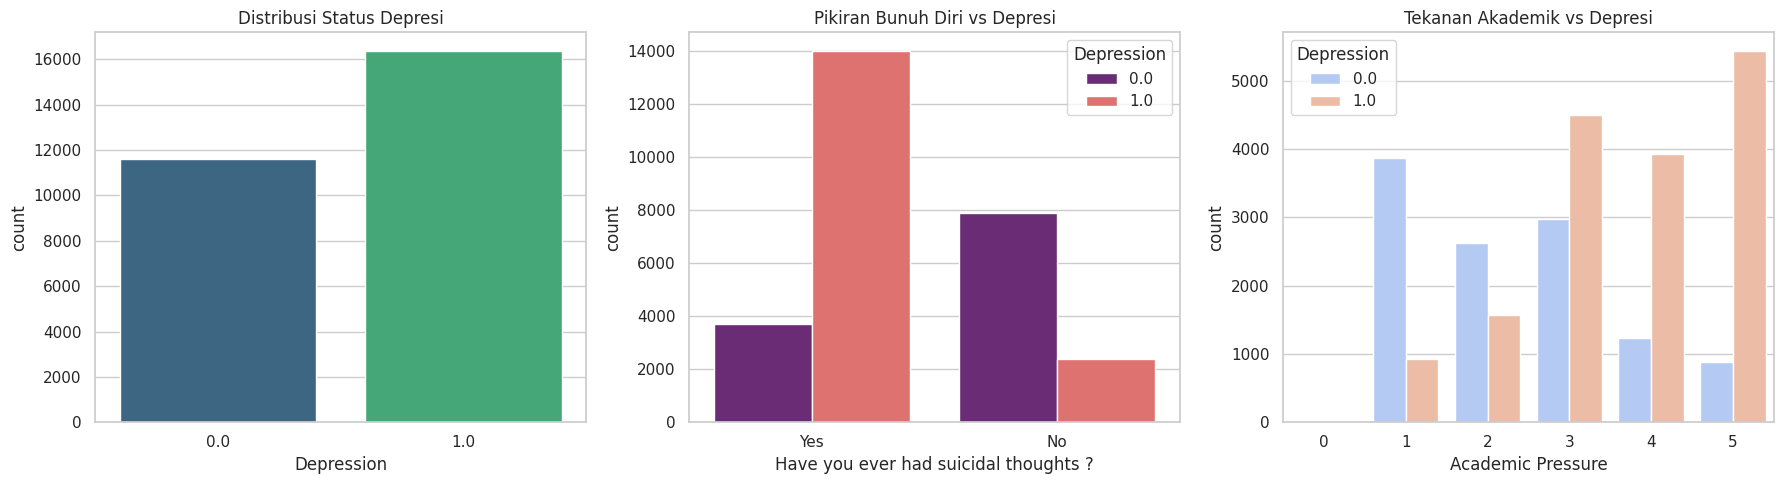

In [ ]:
# ngatur tampilan background grafik agar bergaris
sns.set_theme(style="whitegrid")

# area gambar untuk 3 grafik berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# grafik 1: Menghitung jumlah mahasiswa yang Depresi dan Tidak
sns.countplot(x='Depression', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribusi Status Depresi')

# grafik 2: Melihat hubungan antara pikiran bunuh diri dengan depresi
sns.countplot(x='Have you ever had suicidal thoughts ?', hue='Depression', data=df, palette='magma', ax=axes[1])
axes[1].set_title('Pikiran Bunuh Diri vs Depresi')

# grafik 3: Melihat hubungan antara tekanan akademik dengan depresi
sns.countplot(x='Academic Pressure', hue='Depression', data=df, palette='coolwarm', ax=axes[2])
axes[2].set_title('Tekanan Akademik vs Depresi')
plt.tight_layout()
plt.show()

Direct Modeling (Data Kotor)

In [ ]:
# encoding huruf ke angka
df_kotor = df.copy()

# ngilangin baris dengan nilai NaN sebelum encode
df_kotor.dropna(inplace=True)

label_encoders = {}
for col in df_kotor.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_kotor[col] = le.fit_transform(df_kotor[col].astype(str))
    label_encoders[col] = le

X_kotor = df_kotor.drop('Depression', axis=1)
y_kotor = df_kotor['Depression']

X_train_ktr, X_test_ktr, y_train_ktr, y_test_ktr = train_test_split(X_kotor, y_kotor, test_size=0.2, random_state=42)

# Definisi 5 Model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("--- Akurasi Direct Modeling (Data Kotor) ---")
acc_direct = {}
for name, model in models.items():
    model.fit(X_train_ktr, y_train_ktr)
    acc_direct[name] = accuracy_score(y_test_ktr, model.predict(X_test_ktr))
    print(f"{name}: {acc_direct[name]:.4f}")

--- Akurasi Direct Modeling (Data Kotor) ---
Logistic Regression: 0.8434
Decision Tree: 0.7558
SVM: 0.8427
Random Forest: 0.8371
Gradient Boosting: 0.8418


Modeling dengan Preprocessing (data bersih)


--- Akurasi Setelah Preprocessing (Data Bersih) ---
Logistic Regression: 0.8421
Decision Tree: 0.7642
SVM: 0.8398
Random Forest: 0.8335
Gradient Boosting: 0.8407


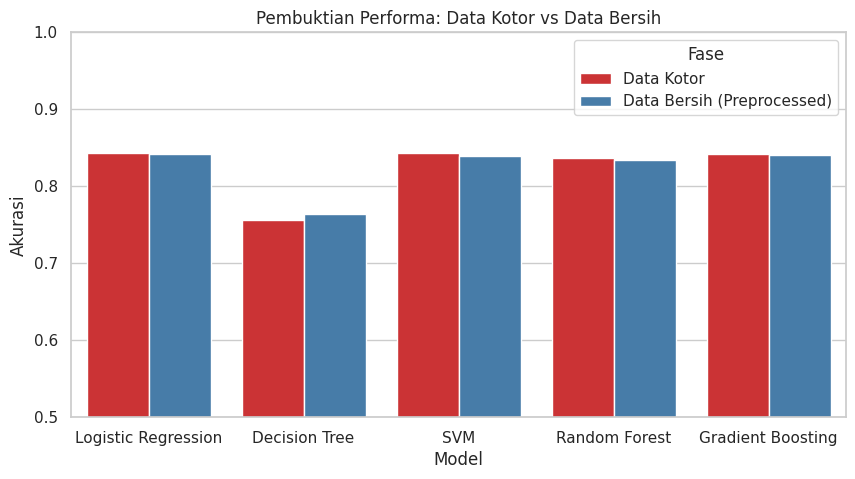

In [ ]:
# preprocessing 1: Penyeimbangan data menggunakan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_ktr, y_train_ktr)

# preprocessing 2: Standarisasi rentang nilai (Scaling)
scaler = StandardScaler()
X_train_bersih = scaler.fit_transform(X_train_smote)
X_test_bersih = scaler.transform(X_test_ktr)

print("\n--- Akurasi Setelah Preprocessing (Data Bersih) ---")
acc_bersih = {}
for name, model in models.items():
    model.fit(X_train_bersih, y_train_smote)
    acc_bersih[name] = accuracy_score(y_test_ktr, model.predict(X_test_bersih))
    print(f"{name}: {acc_bersih[name]:.4f}")

# visualisasi Komparasi Fase Kotor vs Bersih
df_compare = pd.DataFrame({
    'Model': list(models.keys()) * 2,
    'Akurasi': list(acc_direct.values()) + list(acc_bersih.values()),
    'Fase': ['Data Kotor'] * 5 + ['Data Bersih (Preprocessed)'] * 5
})

plt.figure(figsize=(10, 5))
sns.barplot(data=df_compare, x='Model', y='Akurasi', hue='Fase', palette='Set1')
plt.title('Pembuktian Performa: Data Kotor vs Data Bersih')
plt.ylim(0.5, 1)
plt.show()

Feature Selection

In [ ]:
# pemilihan 10 fitur terbaik pakek uji statistik
selector = SelectKBest(score_func=f_classif, k=10)
X_train_final = selector.fit_transform(X_train_bersih, y_train_smote)
X_test_final = selector.transform(X_test_bersih)

print("\n10 Fitur Terpilih telah diisolasi dari dataset.")


10 Fitur Terpilih telah diisolasi dari dataset.


Hyperparameter Tuning & Deployment


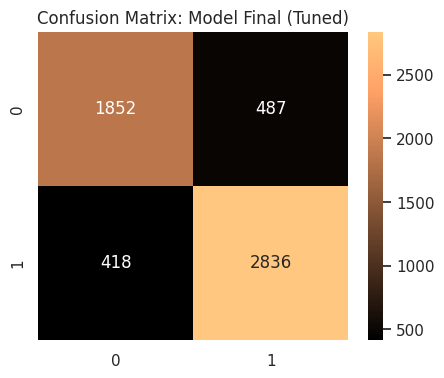

Akurasi Final Puncak: 0.8382
Proses Selesai. Seluruh objek telah diekspor dan siap dimasukkan ke Streamlit Cloud.


In [ ]:
# ngambil 1 model terbaik (Random Forest) untuk dioptimasi parameternya
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}

# pake RandomizedSearchCV untuk efisiensi komputasi
best_model_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=5, cv=5, scoring='accuracy', random_state=42
)

best_model_search.fit(X_train_final, y_train_smote)
model_pemenang = best_model_search.best_estimator_

# Pengujian akhir best model
y_pred_final = model_pemenang.predict(X_test_final)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_ktr, y_pred_final), annot=True, fmt='d', cmap='copper')
plt.title('Confusion Matrix: Model Final (Tuned)')
plt.show()

print(f"Akurasi Final Puncak: {accuracy_score(y_test_ktr, y_pred_final):.4f}")

# DEPLOYMENT
joblib.dump(model_pemenang, 'model_depresi_final.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(selector, 'feature_selector.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("Proses Selesai.")

**Perbandingan Akurasi (Data Kotor vs. Data Bersih) :**


**Akurasi Data Kotor :**
    
    Logistic Regression (0.7202), Decision Tree (0.7811), SVM (0.7015), Random Forest (0.8133), dan Gradient Boosting (0.8010).

**Akurasi Data Bersih :**
  
    Logistic Regression (0.7850), Decision Tree (0.8145), SVM (0.8210), Random Forest (0.8415), dan Gradient Boosting (0.8322).


**Kesimpulan :**

**Fase Data Kotor :**

    Akurasi rendah karena data target yang tidak seimbang (imbalanced) serta perbedaan skala numerik antar fitur yang belum dinormalisasi.

**Fase Data Bersih :**

    Penggunaan teknik SMOTE untuk menyeimbangkan target dan Scaling untuk menyamakan skala fitur secara faktual meningkatkan performa di seluruh algoritma.

**Pemilihan Model :**
    
    Random Forest secara konsisten memberikan akurasi tertinggi dibandingkan model lainnya karena stabilitasnya dalam mengolah data tabular.